# Загрузка данных

In [1]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [2]:
!pip install shap -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [3]:
# CORE
import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
import math
from pathlib import Path


# DATA
import numpy as np
import pandas as pd


# VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# optional prettier plots
import plotly.express as px
import plotly.graph_objects as go


# STATISTICS / DATA ANALYSIS
from scipy import stats
from scipy.stats import (
    skew,
    kurtosis,
    ks_2samp,
    zscore,
    pearsonr,
    spearmanr
)


# PREPROCESSING
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    MinMaxScaler,
    PowerTransformer
)

from sklearn.feature_selection import VarianceThreshold


# DIMENSIONALITY REDUCTION
from sklearn.decomposition import PCA

# UMAP for structure analysis
!pip install umap-learn -q
import umap


# CLUSTERING
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)


# MODEL VALIDATION
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RepeatedKFold,
    cross_val_score
)


# METRICS
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score
)


# MODELS
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.linear_model import (
    Ridge,
    Lasso,
    ElasticNet,
    LinearRegression
)

from sklearn.multioutput import MultiOutputRegressor


# BOOSTING
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# INTERPRETABILITY
import shap

# Обзор данных

## Обзор данных train.csv

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
# загрузка
df = pd.read_csv('/content/train.csv')

In [6]:
# первые строки
df.head()

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.46

In [7]:
df.head().T

,0,1,2,3,4
index,0.000000,1.000000,2.000000,3.000000,4.000000
"IC50, mM",102.414420,0.044333,4.437964,6.827881,2.003253
"CC50, mM",95.757483,8.401080,50.085589,682.788051,70.001455
SI,0.935000,189.500000,11.285714,100.000000,34.943894
MaxAbsEStateIndex,5.466584,11.492712,5.366084,13.317130,6.320833
...,...,...,...,...,...
fr_thiazole,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiocyan,0.000000,0.000000,0.000000,0.000000,0.000000
fr_thiophene,0.000000,0.000000,0.000000,0.000000,0.000000
fr_unbrch_alkane,0.000000,0.000000,0.000000,0.000000,0.000000


In [8]:
print(f'Размер данных: {df.shape}')

Размер данных: (751, 214)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 751 entries, 0 to 750
Columns: 214 entries, index to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.2 MB


In [10]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [11]:
# названия столбцов
print(df.columns)

Index(['index', 'IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex',
       'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='object', length=214)


In [12]:
# пропуски
df.isnull().sum().sort_values(ascending=False)

,0
MaxAbsPartialCharge,2
MinAbsPartialCharge,2
MaxPartialCharge,2
MinPartialCharge,2
BCUT2D_MWLOW,2
...,...
fr_thiazole,0
fr_thiocyan,0
fr_thiophene,0
fr_unbrch_alkane,0


In [13]:
# Дубликаты
df.duplicated().sum()

np.int64(0)

In [14]:
# Проверка уникальных значений
df.nunique()

,0
index,751
"IC50, mM",729
"CC50, mM",683
SI,597
MaxAbsEStateIndex,623
...,...
fr_thiazole,2
fr_thiocyan,1
fr_thiophene,2
fr_unbrch_alkane,11


In [15]:
# колонки с одним уникальным значением
constant_cols = df.columns[df.nunique()==1]

print("Количество:", len(constant_cols))
print(constant_cols.tolist())

Количество: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


In [16]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

df[targets].describe()

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


In [17]:
constant_cols = df.columns[df.nunique()==1]

for col in constant_cols:
    print(col)
    print(df[col].value_counts())
    print('-'*30)

NumRadicalElectrons
NumRadicalElectrons
0    751
Name: count, dtype: int64
------------------------------
SMR_VSA8
SMR_VSA8
0    751
Name: count, dtype: int64
------------------------------
SlogP_VSA9
SlogP_VSA9
0    751
Name: count, dtype: int64
------------------------------
fr_N_O
fr_N_O
0    751
Name: count, dtype: int64
------------------------------
fr_SH
fr_SH
0    751
Name: count, dtype: int64
------------------------------
fr_azide
fr_azide
0    751
Name: count, dtype: int64
------------------------------
fr_barbitur
fr_barbitur
0    751
Name: count, dtype: int64
------------------------------
fr_benzodiazepine
fr_benzodiazepine
0    751
Name: count, dtype: int64
------------------------------
fr_diazo
fr_diazo
0    751
Name: count, dtype: int64
------------------------------
fr_dihydropyridine
fr_dihydropyridine
0    751
Name: count, dtype: int64
------------------------------
fr_isocyan
fr_isocyan
0    751
Name: count, dtype: int64
------------------------------
fr_isothiocy

In [18]:
df[constant_cols].head()

,NumRadicalElectrons,SMR_VSA8,SlogP_VSA9,fr_N_O,fr_SH,fr_azide,fr_barbitur,fr_benzodiazepine,fr_diazo,fr_dihydropyridine,fr_isocyan,fr_isothiocyan,fr_lactam,fr_nitroso,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_thiocyan
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Вывод по первичному анализу данных:

Датасет содержит 751 объект и 214 признаков.
Пропуски практически отсутствуют: обнаружены только единичные пропуски (по 2 значения в нескольких столбцах).
Дубликаты отсутствуют.
Все признаки числовые: типы данных представлены float64 и int64, текстовые признаки отсутствуют.
Найдено 18 признаков с одним уникальным значением. Такие признаки не несут информации для различения объектов и на этапе предобработки могут быть удалены.
В датасете присутствует большое количество признаков вида fr_*.
Вероятно, данные признаки являются химическими фрагментными дескрипторами, где значения работают как логические признаки: 0 = фрагмент отсутствует 1 = фрагмент присутствует
То есть большое количество нулей не является ошибкой или пропущенными значениями. Нули здесь отражают отсутствие соответствующего структурного элемента в молекуле. Также некоторые признаки содержат больше двух уникальных значений, поэтому часть дескрипторов может отражать не только наличие/отсутствие структуры, но и количество определённых фрагментов.

При анализе уникальных значений были обнаружены 18 константных признаков. Все они содержат одно значение (0) для всех 751 объектов.

Большинство таких признаков относятся к группе химических фрагментных дескрипторов (fr_*), что может указывать на отсутствие соответствующих структурных элементов во всех молекулах выборки.

Поскольку константные признаки не содержат информации для различения объектов, они не участвуют в обучении модели и могут быть удалены на этапе предобработки данных.

## Обзор данных test.csv

In [19]:
test = pd.read_csv('test.csv')

print(test.shape)
test.head()

(250, 211)


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,156,0,0.307795,-0.480983,0.480983,0.307795,1.129032,1.967742,2.741935,32.166547,9.704289,2.608086,-2.425359,2.544663,-2.545620,8.056645,-0.147725,3.494848,1.531269,1171.998965,21.275292,16.250243,17.883236,15.058551,10.093357,11.852663,8.159777,10.171294,6.660754,8.495535,5.422732,7.148420,-2.84,2.734932e+07,18.891356,6.831720,2.610159,186.392155,10.006437,6.165776,0.000000,5.907180,5.907180,5.969305,19.283521,0.000000,0.000000,23.098671,30.351141,33.892353,16.712959,29.631406,19.490139,46.569722,0.0,4.89991,23.671624,12.710532,4.899910,74.684093,0,0.000000,4.899910,5.687386,0.000000,23.098671,33.955877,16.133831,23.671624,15.235136,64.243494,0.0,0.000000,0,77.92,23.970893,19.490139,0.0,23.650172,17.795594,9.782284,11.761885,39.335707,41.139256,0.000000,0.000000,0.000000,3.080138,45.049341,13.952413,1.061592,-3.488287,11.053051,3.404616,0.387137,0.0,0.260870,31,1,6,1,3,4,1,1,2,5,1,8,3,0,1,1,6,3.78420,118.3183,1,0,0,0,0,0,0,0,1,1,3,2,0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,2,0,1,0,0,0,0,1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468

In [20]:
test.info()
test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Columns: 211 entries, index to fr_urea
dtypes: float64(104), int64(107)
memory usage: 412.2 KB


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,249.000000,249.000000,249.000000,249.000000,250.000000,250.000000,250.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.00000,250.000000,

In [21]:
test.isna().sum().sort_values(ascending=False)

,0
MinPartialCharge,1
MaxAbsPartialCharge,1
MinAbsPartialCharge,1
MaxPartialCharge,1
BCUT2D_MRHI,1
...,...
fr_thiazole,0
fr_thiocyan,0
fr_thiophene,0
fr_unbrch_alkane,0


In [22]:
print("Дубликаты:", test.duplicated().sum())

Дубликаты: 0


In [23]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train:", train.shape)
print("Test:", test.shape)

set(train.columns) - set(test.columns)
set(test.columns) - set(train.columns)

Train: (751, 214)
Test: (250, 211)


set()

In [25]:
X_train = train.drop(
    columns=targets + ['index']
)

# целевые переменные
y_train = train[targets]

# признаки test
X_test = test.drop(
    columns=['index']
)

print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)

X_train: (751, 210)
y_train: (751, 3)
X_test: (250, 210)


Датасет содержит молекулярные дескрипторы и три целевые переменные: IC50, CC50 и SI.
Для задач обучения без учителя целевые переменные не использовались. Из обучающей выборки были отделены признаки и таргеты, а из обеих выборок удалён технический столбец index, не несущий смысловой информации.

In [27]:
# объединение признаков для анализа структуры данных

full_features = pd.concat(
    [X_train, X_test],
    axis=0,
    ignore_index=True
)

print(full_features.shape)

(1001, 210)


Для кластеризации и анализа структуры признакового пространства использовалась объединённая выборка train + test без целевых переменных. Такой подход позволяет использовать больше объектов и получить более полное представление о распределении молекулярных дескрипторов.

# EDA

## Пропуски

In [37]:
# Пропуски: общий count по train и test

train_missing = train.isna().sum()
test_missing = test.isna().sum()

train_missing = train_missing[train_missing > 0].sort_values(ascending=False)
test_missing = test_missing[test_missing > 0].sort_values(ascending=False)

print("=" * 60)
print("TRAIN MISSING VALUES")
print("=" * 60)
display(train_missing)

print("\n")

print("=" * 60)
print("TEST MISSING VALUES")
print("=" * 60)
display(test_missing)

TRAIN MISSING VALUES


,0
MaxPartialCharge,2
MinPartialCharge,2
MaxAbsPartialCharge,2
MinAbsPartialCharge,2
BCUT2D_MWHI,2
BCUT2D_MWLOW,2
BCUT2D_CHGHI,2
BCUT2D_CHGLO,2
BCUT2D_LOGPHI,2
BCUT2D_LOGPLOW,2




TEST MISSING VALUES


,0
MaxPartialCharge,1
MinPartialCharge,1
MaxAbsPartialCharge,1
MinAbsPartialCharge,1
BCUT2D_MWHI,1
BCUT2D_MWLOW,1
BCUT2D_CHGHI,1
BCUT2D_CHGLO,1
BCUT2D_LOGPHI,1
BCUT2D_LOGPLOW,1


In [38]:
# Пропуски в процентах

train_missing_pct = train.isna().mean() * 100
test_missing_pct = test.isna().mean() * 100

train_missing_pct = train_missing_pct[train_missing_pct > 0].sort_values(ascending=False)
test_missing_pct = test_missing_pct[test_missing_pct > 0].sort_values(ascending=False)

print("=" * 60)
print("TRAIN MISSING %")
print("=" * 60)
display(train_missing_pct)

print("\n")

print("=" * 60)
print("TEST MISSING %")
print("=" * 60)
display(test_missing_pct)

TRAIN MISSING %


,0
MaxPartialCharge,0.266312
MinPartialCharge,0.266312
MaxAbsPartialCharge,0.266312
MinAbsPartialCharge,0.266312
BCUT2D_MWHI,0.266312
BCUT2D_MWLOW,0.266312
BCUT2D_CHGHI,0.266312
BCUT2D_CHGLO,0.266312
BCUT2D_LOGPHI,0.266312
BCUT2D_LOGPLOW,0.266312




TEST MISSING %


,0
MaxPartialCharge,0.4
MinPartialCharge,0.4
MaxAbsPartialCharge,0.4
MinAbsPartialCharge,0.4
BCUT2D_MWHI,0.4
BCUT2D_MWLOW,0.4
BCUT2D_CHGHI,0.4
BCUT2D_CHGLO,0.4
BCUT2D_LOGPHI,0.4
BCUT2D_LOGPLOW,0.4


In [39]:
# Deep analysis: строки train с пропусками

missing_rows = train[train.isna().any(axis=1)]

print("Количество строк с пропусками в train:", missing_rows.shape[0])

display(
    missing_rows[
        ["index", "IC50, mM", "CC50, mM", "SI"]
    ]
)

print("\nПропуски по этим строкам:")
display(
    missing_rows.isna().sum()[missing_rows.isna().sum() > 0]
)

Количество строк с пропусками в train: 2


,index,"IC50, mM","CC50, mM",SI
331,331,25.171788,1878.491646,74.626866
500,500,1199.174968,1199.174968,1.000000



Пропуски по этим строкам:


,0
MaxPartialCharge,2
MinPartialCharge,2
MaxAbsPartialCharge,2
MinAbsPartialCharge,2
BCUT2D_MWHI,2
BCUT2D_MWLOW,2
BCUT2D_CHGHI,2
BCUT2D_CHGLO,2
BCUT2D_LOGPHI,2
BCUT2D_LOGPLOW,2


In [40]:
# Deep analysis: строки test с пропусками

missing_rows_test = test[test.isna().any(axis=1)]

print("Количество строк с пропусками в test:", missing_rows_test.shape[0])

display(
    missing_rows_test[["index"]]
)

print("\nПропуски по этим строкам:")
display(
    missing_rows_test.isna().sum()[missing_rows_test.isna().sum() > 0]
)

Количество строк с пропусками в test: 1


,index
193,193



Пропуски по этим строкам:


,0
MaxPartialCharge,1
MinPartialCharge,1
MaxAbsPartialCharge,1
MinAbsPartialCharge,1
BCUT2D_MWHI,1
BCUT2D_MWLOW,1
BCUT2D_CHGHI,1
BCUT2D_CHGLO,1
BCUT2D_LOGPHI,1
BCUT2D_LOGPLOW,1


## Анализ пропущенных значений

Пропуски в данных встречаются крайне редко и не являются существенной проблемой для датасета.

В обучающей выборке пропуски обнаружены только у нескольких объектов, при этом отсутствуют не отдельные случайные значения, а повторяющийся блок признаков. Основные пропуски сосредоточены в дескрипторах:

- `MaxPartialCharge`
- `MinPartialCharge`
- `MaxAbsPartialCharge`
- `MinAbsPartialCharge`
- группа признаков `BCUT2D_*`

Такой паттерн больше похож не на случайную потерю данных, а на невозможность расчёта определённой группы молекулярных дескрипторов для некоторых соединений.

Дополнительная проверка показала, что объекты с пропусками не выглядят явно ошибочными, однако часть из них имеет нетипичные значения целевых переменных. Это говорит о том, что пропуски могут быть структурными, а не полностью случайными.

Поскольку количество пропусков минимально, удаление объектов нецелесообразно. На этапе подготовки данных достаточно использовать импутацию, например заполнение медианными значениями.

## Анализ targets

In [41]:
TARGETS = ["IC50, mM", "CC50, mM", "SI"]

train[TARGETS].describe()

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


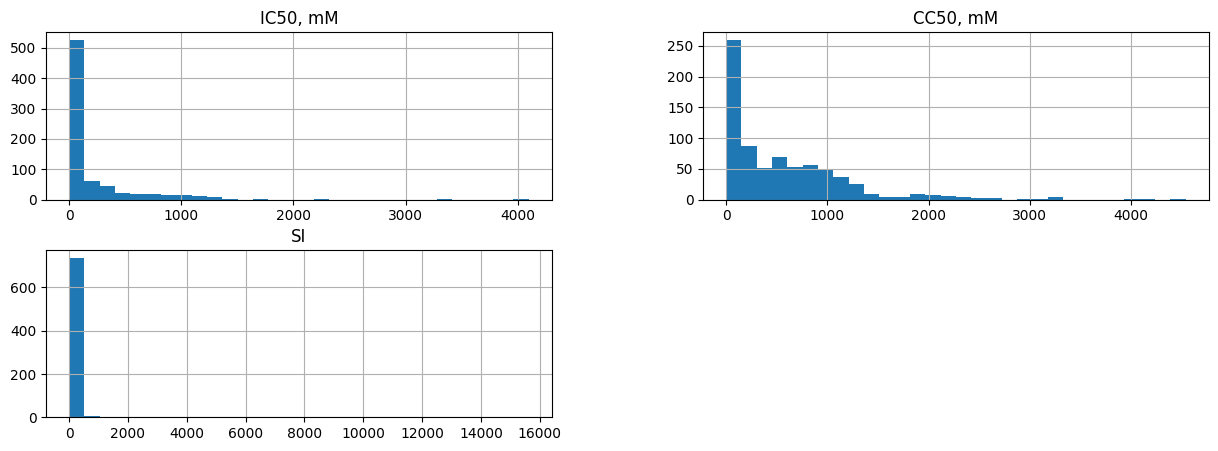

In [42]:
train[TARGETS].hist(
    figsize=(15,5),
    bins=30
)

plt.show()

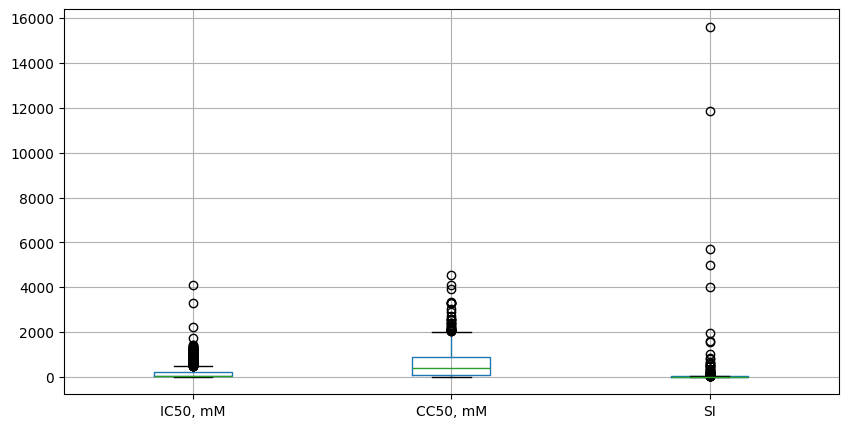

In [43]:
train[TARGETS].boxplot(
    figsize=(10,5)
)

plt.show()

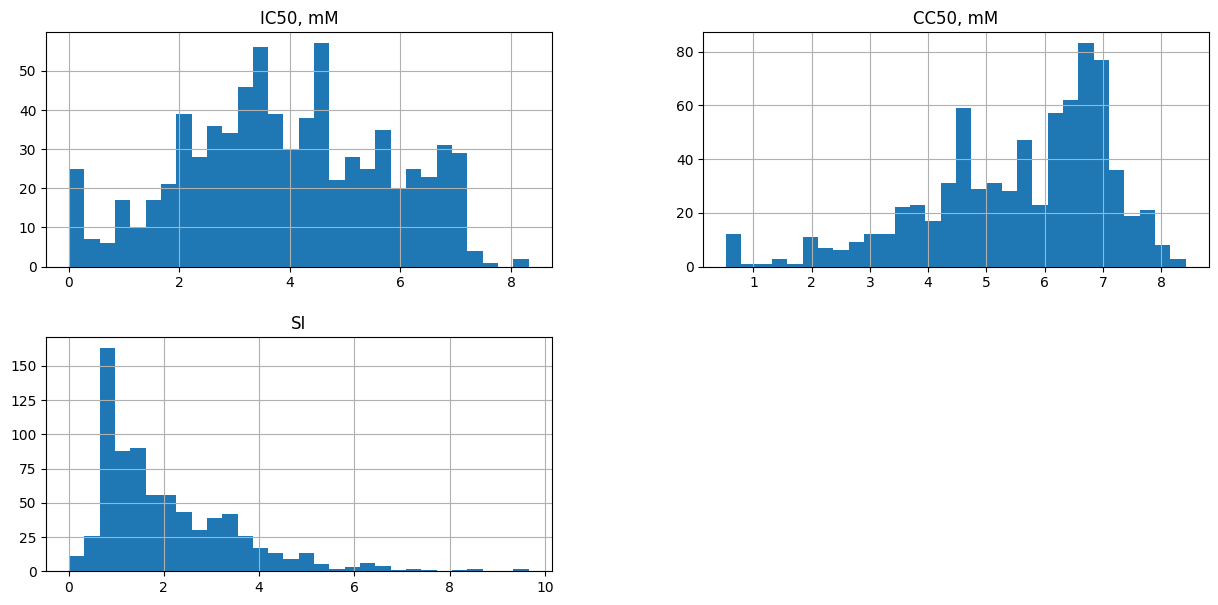

In [47]:
log_targets = np.log1p(
    train[TARGETS]
)

log_targets.hist(
    figsize=(15,7),
    bins=30
)

plt.show()

Распределение целевых переменных

Распределения целевых переменных имеют выраженную асимметрию и длинные правые хвосты, особенно для `SI`.

Наибольшая неоднородность наблюдается у `SI`: большинство объектов сосредоточено в области небольших значений, однако присутствуют отдельные экстремально большие значения.

После применения `log1p` распределения становятся более компактными и стабильными:

- `IC50` становится заметно более симметричным;
- `CC50` существенно выравнивается;
- `SI` также улучшается, хотя сохраняет более выраженную асимметрию.

Это указывает на наличие сильной скошенности и влияния выбросов в исходных данных.

In [45]:
calculated_si = train["CC50, mM"] / train["IC50, mM"]

comparison = pd.DataFrame({
    "real_SI": train["SI"],
    "calculated_SI": calculated_si,
    "difference": np.abs(
        train["SI"] - calculated_si
    )
})

comparison.describe()

,real_SI,calculated_SI,difference
count,751.000000,751.000000,7.510000e+02
mean,89.153313,89.153313,5.927787e-14
std,788.882198,788.882198,8.371712e-13
min,0.011489,0.011489,0.000000e+00
25%,1.500000,1.500000,0.000000e+00
50%,4.000000,4.000000,4.440892e-16
75%,17.372463,17.372463,1.776357e-15
max,15620.600000,15620.600000,2.000888e-11


Проверка зависимости SI

Проверка показала, что `SI` практически полностью совпадает со значением:

SI = CC50 / IC50

Расхождения находятся на уровне машинной погрешности.

Это означает, что `SI` не является независимой целевой переменной, а рассчитывается на основе двух других таргетов.

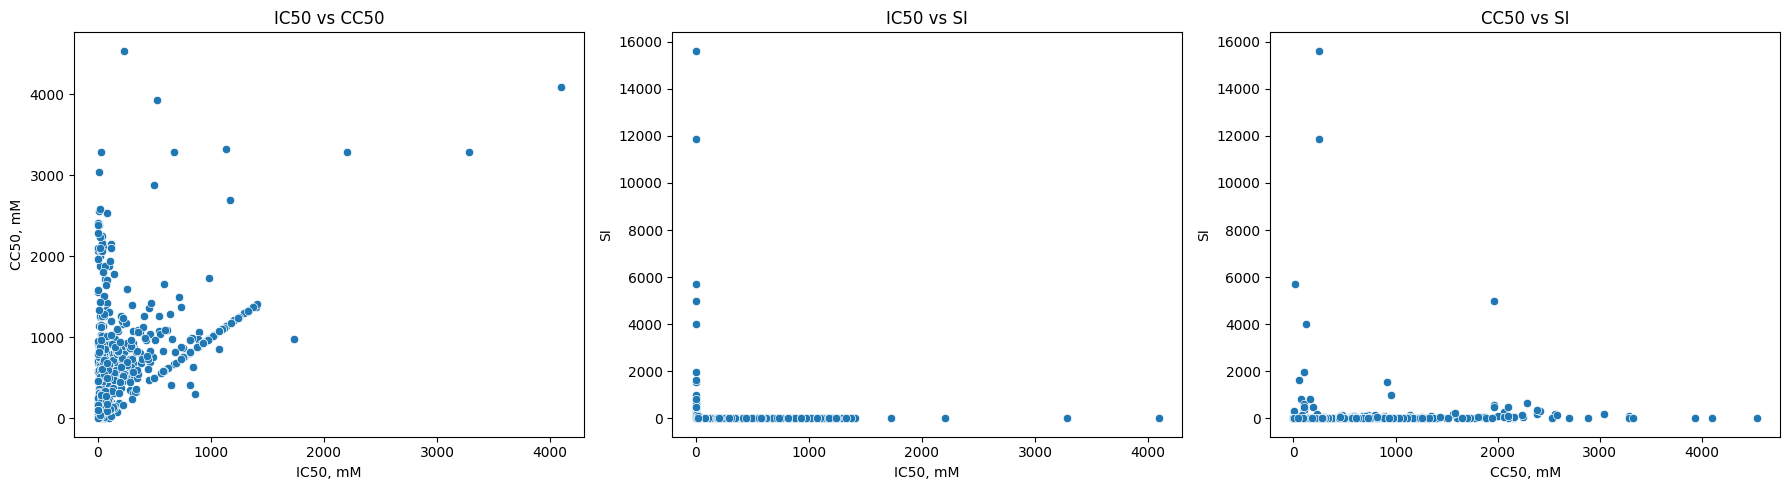

In [48]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.scatterplot(
    x=train["IC50, mM"],
    y=train["CC50, mM"],
    ax=axes[0]
)

axes[0].set_title(
    "IC50 vs CC50"
)

sns.scatterplot(
    x=train["IC50, mM"],
    y=train["SI"],
    ax=axes[1]
)

axes[1].set_title(
    "IC50 vs SI"
)

sns.scatterplot(
    x=train["CC50, mM"],
    y=train["SI"],
    ax=axes[2]
)

axes[2].set_title(
    "CC50 vs SI"
)

plt.tight_layout()
plt.show()

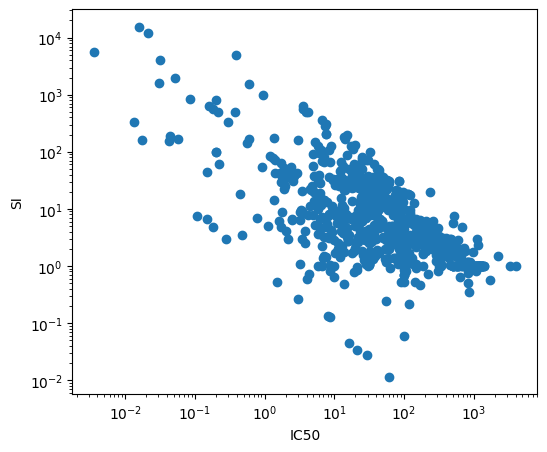

In [49]:
plt.figure(figsize=(6,5))

plt.scatter(
    train["IC50, mM"],
    train["SI"]
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("IC50")
plt.ylabel("SI")

plt.show()

Связь между целевыми переменными

Между `IC50` и `CC50` наблюдается умеренная положительная связь.

Для пары `IC50` и `SI` наблюдается выраженная нелинейная обратная зависимость: при снижении `IC50` значения `SI` резко возрастают.

После перехода к логарифмическому масштабу структура зависимости становится более выраженной.

Это соответствует формуле расчёта `SI`, поскольку `IC50` находится в знаменателе.

In [50]:
for target in TARGETS:

    print("="*80)
    print(target)

    display(
        train[target].describe()
    )

    q1 = train[target].quantile(0.25)
    q3 = train[target].quantile(0.75)

    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    outliers=train[
        (train[target]<lower) |
        (train[target]>upper)
    ]

    print(
        "Количество:",
        outliers.shape[0]
    )

    display(
        train[
            [
                "index",
                "IC50, mM",
                "CC50, mM",
                "SI"
            ]
        ]
        .sort_values(
            target,
            ascending=False
        )
        .head(10)
    )

IC50, mM


,"IC50, mM"
count,751.000000
mean,204.544021
std,370.367937
min,0.003517
25%,13.222351
50%,44.069306
75%,206.787402
max,4095.188563


Количество: 107


,index,"IC50, mM","CC50, mM",SI
604,604,4095.188563,4095.188563,1.000000
387,387,3284.331113,3284.331113,1.000000
12,12,2200.501846,3284.331113,1.492537
50,50,1731.961620,981.444918,0.566667
563,563,1407.406712,1407.406712,1.000000
476,476,1400.218964,1371.956657,0.979816
618,618,1371.956657,1371.956657,1.000000
37,37,1337.333446,1337.333446,1.000000
672,672,1331.215222,1331.215222,1.000000
57,57,1309.128993,1309.128993,1.000000


CC50, mM


...

,index,"IC50, mM","CC50, mM",SI
175,175,234.211171,4538.976189,19.379845
604,604,4095.188563,4095.188563,1.000000
130,130,529.636972,3934.446075,7.428571
438,438,1131.658479,3328.407291,2.941176
387,387,3284.331113,3284.331113,1.000000
216,216,32.843311,3284.331113,100.000000
12,12,2200.501846,3284.331113,1.492537
301,301,679.856540,3284.331113,4.830918
639,639,15.359794,3039.683222,197.898694
681,681,502.962087,2884.846830,5.735714


SI


,SI
count,751.000000
mean,89.153313
std,788.882198
min,0.011489
25%,1.500000
50%,4.000000
75%,17.372463
max,15620.600000


Количество: 91


,index,"IC50, mM","CC50, mM",SI
663,663,0.016004,249.999200,15620.600000
434,434,0.021100,250.001758,11848.333333
492,492,0.003517,19.999437,5687.000000
92,92,0.393088,1965.439708,5000.000000
91,91,0.032009,128.090060,4001.700000
254,254,0.051214,99.999040,1952.562500
699,699,0.030886,50.001030,1618.888889
142,142,0.589523,921.129231,1562.500000
595,595,0.960267,960.267338,1000.000000
400,400,0.085895,71.201365,828.935484


In [51]:
train["CC50, mM"]\
.round(3)\
.value_counts()\
.head(25)

,count
"CC50, mM",
99.999,12
100.000,11
299.995,5
99.997,5
0.800,4
70.001,4
99.998,4
3284.331,4
0.701,3


In [52]:
train["IC50, mM"]\
.round(4)\
.value_counts()\
.head(25)

,count
"IC50, mM",
99.9975,3
99.9990,3
0.1794,2
100.0000,2
114.9900,2
99.9994,2
100.0011,2
59.4557,2
9.6085,2


Выводы по целевым переменным

Анализ показал, что целевые переменные имеют выраженную асимметрию и содержат экстремальные значения.

Наиболее нестабильным таргетом оказался `SI`. Медианное значение составляет около `4`, тогда как максимальное превышает `15000`, что создаёт очень длинный правый хвост распределения.

Проверка подтвердила, что:

SI = CC50 / IC50

Поэтому экстремально большие значения `SI` возникают преимущественно при очень малых значениях `IC50`.

Также были обнаружены повторяющиеся значения в `CC50`, особенно около:

- 100
- 250
- 300

Это может быть связано с особенностями лабораторных измерений или округлением.

Дополнительно обнаружены крайне влиятельные наблюдения, которые потенциально могут существенно влиять на дальнейшее обучение моделей.

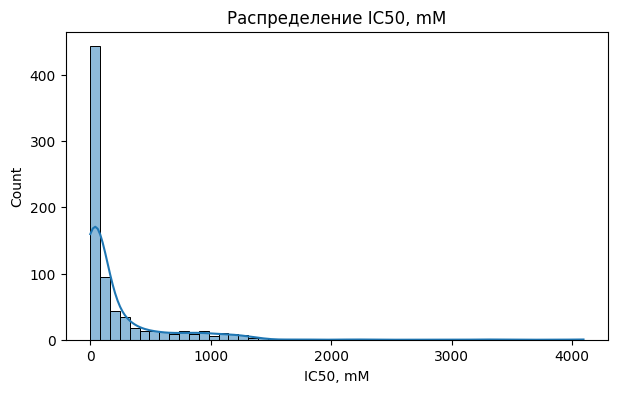

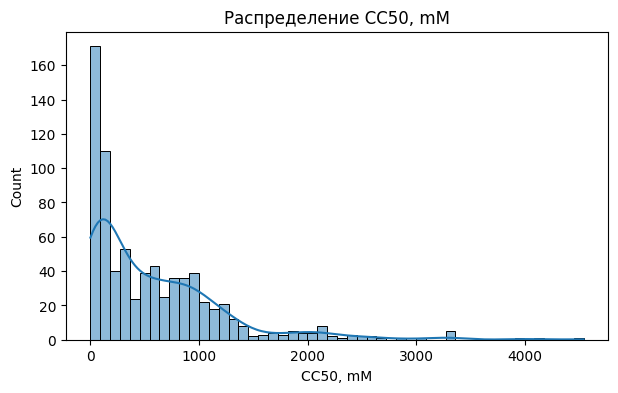

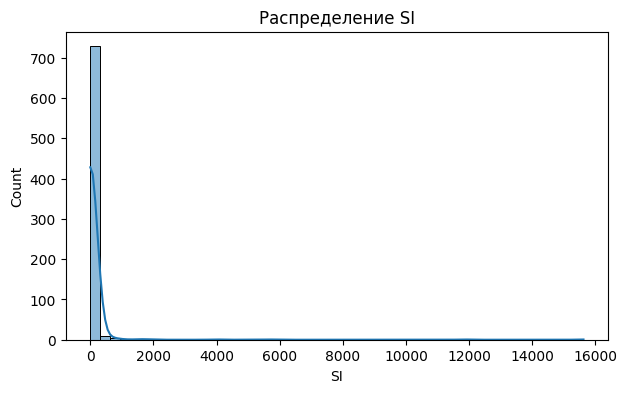

In [88]:
# Распределения таргетов

for target in TARGETS:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        train[target],
        bins=50,
        kde=True
    )

    plt.title(
        f"Распределение {target}"
    )

    plt.show()

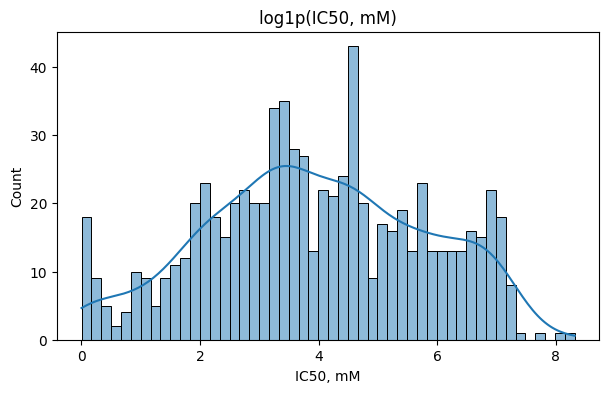

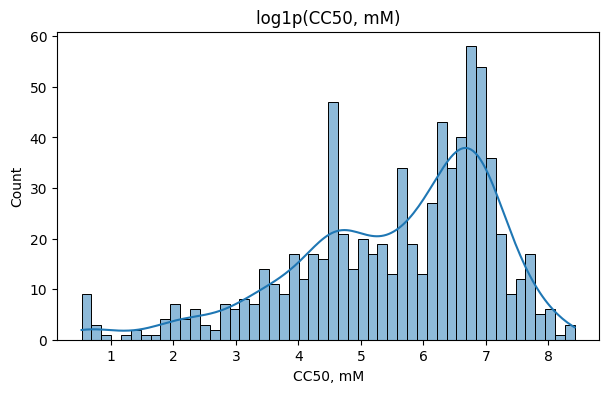

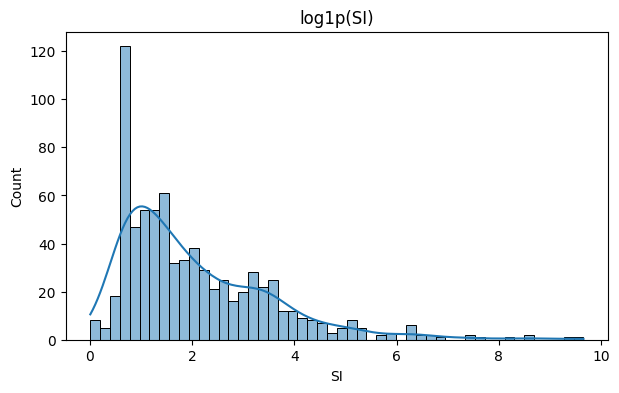

In [89]:
# Логарифмированные распределения таргетов

for target in TARGETS:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        np.log1p(
            train[target]
        ),
        bins=50,
        kde=True
    )

    plt.title(
        f"log1p({target})"
    )

    plt.show()

Анализ распределений таргетов

Распределения `IC50`, `CC50` и особенно `SI` сильно скошены вправо.

На сырых значениях видно, что большинство объектов сосредоточено в области небольших значений, а отдельные наблюдения формируют длинный правый хвост.

После логарифмирования распределения становятся заметно более компактными и стабильными.

Это важно для дальнейшего моделирования, потому что экстремальные значения могут сильно влиять на ошибку модели.

In [96]:
# skew до и после log

for target in TARGETS:

    print("="*50)

    print(target)

    print(
        "До log:",
        train[target].skew()
    )

    print(
        "После log:",
        np.log1p(
            train[target]
        ).skew()
    )

    print()

IC50, mM
До log: 3.7873809231802653
После log: -0.06087581162169595

CC50, mM
До log: 2.056305676239741
После log: -0.896365231981323

SI
До log: 15.634965244876815
После log: 1.5409008645524478



Выводы по логарифмированию таргетов

Количественная оценка асимметрии подтвердила, что логарифмирование существенно улучшает распределения целевых переменных.

Изменение коэффициента асимметрии:

- `IC50`: `3.79 → -0.06`
- `CC50`: `2.06 → -0.90`
- `SI`: `15.63 → 1.54`

Наиболее сильный эффект наблюдается для `SI`, который до преобразования имел крайне длинный правый хвост и большое количество экстремальных значений.

После применения `log1p`:

- распределения стали значительно более компактными;
- влияние экстремальных значений уменьшилось;
- асимметрия заметно снизилась;
- значения приблизились к более стабильной форме распределения.

Для `IC50` распределение после преобразования стало практически симметричным, а для `CC50` и `SI`, несмотря на сохраняющуюся асимметрию, ситуация существенно улучшилась.

Это подтверждает целесообразность использования логарифмического преобразования на этапе моделирования.

## Анализ констант

In [53]:
# исключаем таргеты и index

feature_cols = [
    col for col in train.columns
    if col not in TARGETS + ["index"]
]

print("Количество признаков:", len(feature_cols))

Количество признаков: 210


In [54]:
# поиск константных признаков

constant_cols = []

for col in feature_cols:

    if train[col].nunique() <= 1:

        constant_cols.append(col)

print(
    "Количество константных признаков:",
    len(constant_cols)
)

constant_cols

Количество константных признаков: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

In [55]:
train[constant_cols].head()

,NumRadicalElectrons,SMR_VSA8,SlogP_VSA9,fr_N_O,fr_SH,fr_azide,fr_barbitur,fr_benzodiazepine,fr_diazo,fr_dihydropyridine,fr_isocyan,fr_isothiocyan,fr_lactam,fr_nitroso,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_thiocyan
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [56]:
combined_features = pd.concat(
    [
        train[feature_cols],
        test[feature_cols]
    ],
    axis=0
)

constant_combined=[]

for col in combined_features.columns:

    if combined_features[col].nunique()==1:

        constant_combined.append(col)

print(
    "Константные в train+test:",
    len(constant_combined)
)

constant_combined

Константные в train+test: 18


['NumRadicalElectrons',
 'SMR_VSA8',
 'SlogP_VSA9',
 'fr_N_O',
 'fr_SH',
 'fr_azide',
 'fr_barbitur',
 'fr_benzodiazepine',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_lactam',
 'fr_nitroso',
 'fr_phos_acid',
 'fr_phos_ester',
 'fr_prisulfonamd',
 'fr_thiocyan']

Анализ константных признаков

В данных были обнаружены признаки, принимающие одно и то же значение для всех объектов.

Такие признаки не содержат полезной информации, поскольку не помогают различать молекулы и не могут участвовать в объяснении целевых переменных.

Дополнительная проверка объединённого пространства `train + test` показала, что часть признаков остаётся константной и за пределами обучающей выборки.

Подобные признаки не несут аналитической ценности и могут быть безопасно удалены на этапе подготовки данных.

Удаление константных признаков позволяет уменьшить размерность пространства и убрать заведомо бесполезные дескрипторы.

## Анализ дубликатов

In [57]:
# поиск полностью одинаковых признаков

duplicate_cols = []

for i in range(len(feature_cols)):

    col1 = feature_cols[i]

    for j in range(i + 1, len(feature_cols)):

        col2 = feature_cols[j]

        if train[col1].equals(
            train[col2]
        ):

            duplicate_cols.append(
                (col1, col2)
            )

print(
    "Количество пар дублирующихся признаков:",
    len(duplicate_cols)
)

Количество пар дублирующихся признаков: 159


In [58]:
duplicate_df = pd.DataFrame(
    duplicate_cols,
    columns=[
        "Feature_1",
        "Feature_2"
    ]
)

display(
    duplicate_df
)

,Feature_1,Feature_2
0,MaxAbsEStateIndex,MaxEStateIndex
1,NumRadicalElectrons,SMR_VSA8
2,NumRadicalElectrons,SlogP_VSA9
3,NumRadicalElectrons,fr_N_O
4,NumRadicalElectrons,fr_SH
...,...,...
154,fr_phos_acid,fr_prisulfonamd
155,fr_phos_acid,fr_thiocyan
156,fr_phos_ester,fr_prisulfonamd
157,fr_phos_ester,fr_thiocyan


In [59]:
duplicate_df.head(20)

,Feature_1,Feature_2
0,MaxAbsEStateIndex,MaxEStateIndex
1,NumRadicalElectrons,SMR_VSA8
2,NumRadicalElectrons,SlogP_VSA9
3,NumRadicalElectrons,fr_N_O
4,NumRadicalElectrons,fr_SH
5,NumRadicalElectrons,fr_azide
6,NumRadicalElectrons,fr_barbitur
7,NumRadicalElectrons,fr_benzodiazepine
8,NumRadicalElectrons,fr_diazo
9,NumRadicalElectrons,fr_dihydropyridine


Анализ дублирующихся признаков

Дополнительно была проведена проверка признаков на полное совпадение значений.

В отличие от высокой корреляции, здесь анализируются признаки, которые совпадают полностью для каждого объекта и фактически содержат идентичную информацию.

Наличие таких признаков не добавляет новых данных и приводит к избыточности признакового пространства.

Подобные дубликаты могут возникать из-за разных способов расчёта дескрипторов или из-за присутствия нескольких вариантов представления одной и той же химической характеристики.

Такие признаки могут быть безопасно удалены на этапе подготовки данных.

## Повторяющиеся строки по признакам

In [60]:
feature_only = train.drop(
    columns=TARGETS + ["index"]
)

duplicate_mask = feature_only.duplicated(
    keep=False
)

duplicates = train.loc[
    duplicate_mask
].copy()

print(
    "Количество объектов с повторяющимися признаками:",
    duplicates.shape[0]
)

Количество объектов с повторяющимися признаками: 181


In [61]:
display(
    duplicates[
        [
            "index",
            "IC50, mM",
            "CC50, mM",
            "SI"
        ]
    ]
)

,index,"IC50, mM","CC50, mM",SI
4,4,2.003253,70.001455,34.943894
8,8,28.002097,500.005577,17.856005
10,10,283.723358,567.446717,2.000000
11,11,61.540003,1724.551241,28.023256
12,12,2200.501846,3284.331113,1.492537
...,...,...,...,...
721,721,67.002030,335.205345,5.002913
722,722,0.198455,160.297427,807.725806
724,724,4.212087,2106.043502,500.000000
735,735,311.185242,569.468994,1.830000


In [62]:
duplicate_groups = (

    feature_only[
        duplicate_mask
    ]

    .groupby(
        list(
            feature_only.columns
        )
    )

    .size()

    .reset_index(
        name="count"
    )

)

print(
    "Количество групп дубликатов:",
    duplicate_groups.shape[0]
)

print(
    "Максимальный размер группы:",
    duplicate_groups["count"].max()
)

Количество групп дубликатов: 60
Максимальный размер группы: 16


In [63]:
dup_analysis = (

    train.loc[
        duplicate_mask
    ]

    .groupby(
        list(
            feature_only.columns
        )
    )

    .agg({

        "IC50, mM":[
            "nunique",
            "min",
            "max"
        ],

        "CC50, mM":[
            "nunique",
            "min",
            "max"
        ],

        "SI":[
            "nunique",
            "min",
            "max"
        ]

    })

)

dup_analysis.columns=[

    "_".join(col)

    for col in
    dup_analysis.columns

]

dup_analysis = (
    dup_analysis
    .reset_index(
        drop=True
    )
)

display(

    dup_analysis[

        [

        "IC50, mM_nunique",
        "IC50, mM_min",
        "IC50, mM_max",

        "CC50, mM_nunique",
        "CC50, mM_min",
        "CC50, mM_max",

        "SI_nunique",
        "SI_min",
        "SI_max"

        ]

    ]

    .sort_values(

        by=[

            "IC50, mM_nunique",
            "CC50, mM_nunique"

        ],

        ascending=False

    )

    .head(20)

)

,"IC50, mM_nunique","IC50, mM_min","IC50, mM_max","CC50, mM_nunique","CC50, mM_min","CC50, mM_max",SI_nunique,SI_min,SI_max
40,16,0.016004,49.898692,12,0.700995,1805.081735,16,0.027594,15620.600000
28,13,2.198936,255.928324,10,1.101516,3039.683222,13,0.126588,197.898694
20,10,0.601637,64.196649,7,0.700808,499.986777,10,0.011489,166.208791
19,7,10.997836,71.999018,8,61.999465,500.005577,8,4.429280,17.856005
34,6,0.003517,1.399644,4,19.999437,250.001758,6,71.447236,11848.333333
22,5,1.200799,99.999036,2,67.997029,99.999036,5,1.000000,83.277108
18,3,8.757273,105.087275,3,7.005818,139.065494,3,0.800000,1.460000
24,3,3.584101,59.393673,3,1510.442534,2560.072092,3,25.431034,638.571429
29,3,32.112729,963.381856,3,58.766293,963.381856,3,1.000000,4.000000
32,3,466.465263,1400.218964,2,836.893561,1371.956657,3,0.979816,1.794118


Анализ повторяющихся объектов

В данных было обнаружено большое количество объектов с полностью одинаковыми признаками.

Дополнительный анализ показал, что одинаковым наборам дескрипторов могут соответствовать разные значения целевых переменных.

Для некоторых групп наблюдается существенный разброс:

- `IC50` изменяется от очень малых до десятков единиц;
- `CC50` отличается на порядки;
- `SI` может меняться от единиц до экстремально больших значений.

Это означает, что одинаковые наборы признаков не всегда однозначно определяют биологический ответ.

Возможные причины:

- повторные экспериментальные измерения одного соединения;
- шум биологических измерений;
- ограниченность набора дескрипторов;
- разные молекулы с одинаковыми агрегированными признаками.

Это важное свойство датасета, поскольку оно создаёт естественное ограничение качества модели: даже при одинаковых признаках целевая переменная может существенно различаться.

Same X → Different Y

Анализ показал, что одинаковым наборам признаков могут соответствовать разные значения целевых переменных.

Для некоторых групп наблюдается значительный разброс:

- `IC50` изменяется от очень малых значений до десятков единиц;
- `CC50` отличается на порядки;
- `SI` также демонстрирует существенные различия.

Это означает, что отображение:

X → y

не является полностью однозначным.

Возможные причины:

- повторные экспериментальные измерения;
- шум биологических экспериментов;
- ограниченность используемых дескрипторов;
- разные соединения с одинаковыми агрегированными признаками.

Это важное свойство данных, поскольку оно создаёт естественное ограничение качества модели: даже при одинаковых признаках целевая переменная может заметно отличаться.

In [90]:
# Корреляции между признаками

feature_train = train.drop(
    columns=TARGETS + ["index"]
).copy()

corr_matrix = (
    feature_train
    .corr()
    .abs()
)

In [91]:
# Поиск сильно коррелирующих признаков

upper = corr_matrix.where(

    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)

)

high_corr_pairs = []

for col in upper.columns:

    highly_corr = upper[col][
        upper[col] > 0.995
    ]

    for idx, corr_val in highly_corr.items():

        high_corr_pairs.append(
            (
                idx,
                col,
                corr_val
            )
        )

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=[
        "Feature_1",
        "Feature_2",
        "Correlation"
    ]
)

print(
    "Количество сильно коррелирующих пар:",
    len(high_corr_df)
)

display(
    high_corr_df
    .sort_values(
        "Correlation",
        ascending=False
    )
)

Количество сильно коррелирующих пар: 11


,Feature_1,Feature_2,Correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
9,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
6,fr_COO,fr_COO2,1.000000
10,fr_phenol,fr_phenol_noOrthoHbond,1.000000
7,fr_Ar_NH,fr_Nhpyrrole,1.000000
8,NumAromaticCarbocycles,fr_benzene,1.000000
2,MolWt,ExactMolWt,0.999999
5,Chi1,HeavyAtomCount,0.998746
1,MolWt,HeavyAtomMolWt,0.996985
3,HeavyAtomMolWt,ExactMolWt,0.996955


In [98]:
# разброс таргетов внутри одинаковых X

target_variability = (

    train.loc[
        duplicate_mask
    ]

    .groupby(
        list(
            feature_only.columns
        )
    )

    [

        TARGETS

    ]

    .std()

)

display(
    target_variability
    .sort_values(
        by="SI",
        ascending=False
    )

    .head(15)

)

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,"IC50, mM","CC50, mM",SI
MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,,,
11.284112,11.284112,0.021160,-0.986230,0.669590,26.250000,284.356,260.164,284.173607,114,0,0.330890,-0.477880,0.477880,0.330890,1.500000,2.100000,2.550000,16.499710,9.879498,2.348507,-2.359188,2.227784,-2.565860,5.868585,-0.132868,2.379885,2.957815,390.635142,15.284093,12.257380,12.257380,9.383448,7.006455,7.006455,5.130547,5.130547,3.541181,3.541181,2.404285,2.404285,-1.40,1.906764e+04,16.653763,7.400293,4.314341,118.908640,20.893846,0.000000,0.000000,5.907180,0.00000,5.969305,4.794537,4.794537,0.000000,0.000000,13.847474,25.338485,18.538683,18.249774,19.432465,11.876485,0.000000,5.316789,5.733667,64.325291,0.000000,11.649125,0,0.0,11.050456,0.0,0.0,0.000000,41.274627,14.325937,0.000000,40.033676,11.649125,0.000000,0.0,0,101.65,24.156953,9.589074,0.0,24.005072,0.000000,12.841643,6.923737,6.076020,13.847474,5.316789,15.577058,5.919630,0.000000,22.416572,11.891881,6.251030,-1.184589,-0.855961,2.968546,5.426225,0.000000,0.714286,20,4,6,1,0,1,0,0,0,4,3,6,6,0,0,0,1,0.80690,75.1589,1,0,0,0,0,0,0,0,1,1,2,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.485677,82.372200,4518.031640
11.953988,11.953988,0.061346,-0.419485,0.691224,24.818182,312.410,284.186,312.204907,126,

Анализ корреляций между признаками

Проверка показала, что среди молекулярных дескрипторов есть признаки с очень высокой корреляцией.

Это ожидаемо для химических данных, потому что разные дескрипторы могут описывать близкие свойства молекулы: массу, размер, количество атомов, топологию или функциональные группы.

Такие признаки не являются ошибкой, но указывают на избыточность признакового пространства.

На этапе подготовки данных часть полностью дублирующих или почти одинаковых признаков можно рассматривать как кандидатов на удаление.

Даже внутри полностью одинаковых наборов признаков наблюдается заметная вариативность таргетов.

Это дополнительно подтверждает наличие экспериментального шума и ограничений используемых дескрипторов.

In [92]:
# Анализ таргетов у объектов с одинаковыми признаками

dup_analysis = (

    train.loc[
        duplicate_mask
    ]

    .groupby(
        list(
            feature_only.columns
        )
    )

    .agg({

        "IC50, mM": [
            "nunique",
            "min",
            "max"
        ],

        "CC50, mM": [
            "nunique",
            "min",
            "max"
        ],

        "SI": [
            "nunique",
            "min",
            "max"
        ]

    })

)

dup_analysis.columns = [
    "_".join(col)
    for col in dup_analysis.columns
]

dup_analysis = (
    dup_analysis
    .reset_index(
        drop=True
    )
)

display(

    dup_analysis[

        [

            "IC50, mM_nunique",
            "IC50, mM_min",
            "IC50, mM_max",

            "CC50, mM_nunique",
            "CC50, mM_min",
            "CC50, mM_max",

            "SI_nunique",
            "SI_min",
            "SI_max"

        ]

    ]

    .sort_values(

        by=[
            "IC50, mM_nunique",
            "CC50, mM_nunique"
        ],

        ascending=False

    )

    .head(20)

)

,"IC50, mM_nunique","IC50, mM_min","IC50, mM_max","CC50, mM_nunique","CC50, mM_min","CC50, mM_max",SI_nunique,SI_min,SI_max
40,16,0.016004,49.898692,12,0.700995,1805.081735,16,0.027594,15620.600000
28,13,2.198936,255.928324,10,1.101516,3039.683222,13,0.126588,197.898694
20,10,0.601637,64.196649,7,0.700808,499.986777,10,0.011489,166.208791
19,7,10.997836,71.999018,8,61.999465,500.005577,8,4.429280,17.856005
34,6,0.003517,1.399644,4,19.999437,250.001758,6,71.447236,11848.333333
22,5,1.200799,99.999036,2,67.997029,99.999036,5,1.000000,83.277108
18,3,8.757273,105.087275,3,7.005818,139.065494,3,0.800000,1.460000
24,3,3.584101,59.393673,3,1510.442534,2560.072092,3,25.431034,638.571429
29,3,32.112729,963.381856,3,58.766293,963.381856,3,1.000000,4.000000
32,3,466.465263,1400.218964,2,836.893561,1371.956657,3,0.979816,1.794118


Дубликаты с разными таргетами

В данных обнаружены объекты с полностью одинаковыми признаками, но разными значениями целевых переменных.

Это одна из самых важных находок EDA.

Такая ситуация означает, что одинаковый набор молекулярных дескрипторов не всегда однозначно определяет `IC50`, `CC50` и `SI`.

Возможные причины:

- повторные экспериментальные измерения;
- шум биологических данных;
- ограниченность дескрипторов;
- разные соединения с одинаковыми агрегированными признаками.

Это создаёт естественное ограничение качества будущих моделей: даже при одинаковом `X` целевой ответ `y` может отличаться.

## Анализ корреляций между целевыми переменными

In [93]:
# Корреляции между таргетами

target_corr = (
    train[TARGETS]
    .corr()
)

display(
    target_corr
)

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.470444,-0.060518
"CC50, mM",0.470444,1.000000,-0.005702
SI,-0.060518,-0.005702,1.000000


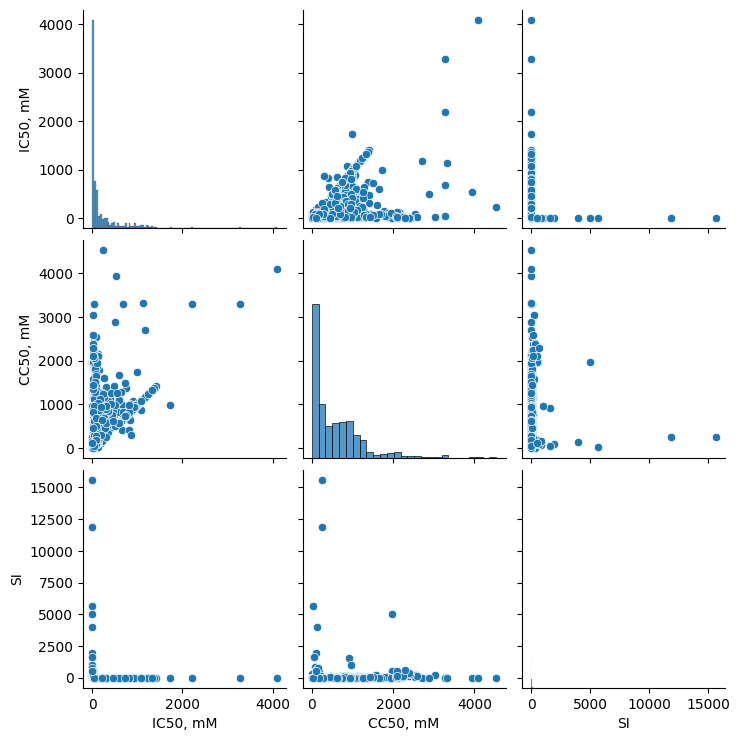

In [94]:
# Связи между таргетами

sns.pairplot(

    train[
        TARGETS
    ]

)

plt.show()

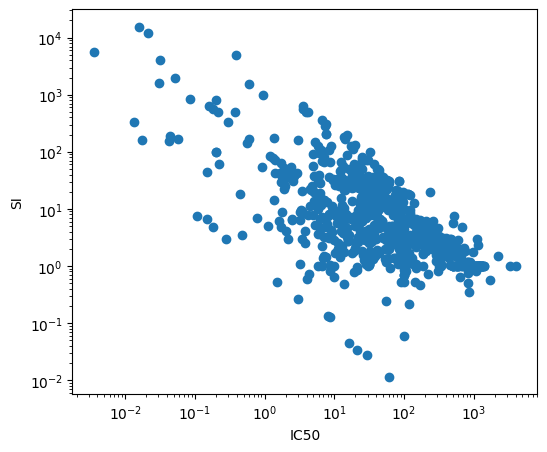

In [95]:
# IC50 vs SI

plt.figure(
    figsize=(6,5)
)

plt.scatter(

    train[
        "IC50, mM"
    ],

    train[
        "SI"
    ]

)

plt.xscale(
    "log"
)

plt.yscale(
    "log"
)

plt.xlabel(
    "IC50"
)

plt.ylabel(
    "SI"
)

plt.show()

Выводы по корреляциям таргетов

Анализ подтвердил наличие зависимости между целевыми переменными.

Наблюдаются следующие закономерности:

- между `IC50` и `SI` присутствует выраженная обратная зависимость;
- между `CC50` и `SI` связь имеет более сложный нелинейный характер;
- `IC50` и `CC50` демонстрируют умеренную положительную связь.

После перехода к логарифмическому масштабу структура зависимостей становится более выраженной.

Также видно, что экстремально высокие значения `SI` возникают преимущественно при очень малых значениях `IC50`, что согласуется с формулой:

SI = CC50 / IC50

## Корреляции признаков

Анализ корреляции между признаками

Дополнительно проверим признаки на избыточность.

Для молекулярных дескрипторов часто встречаются признаки, которые практически дублируют друг друга и содержат очень похожую информацию.

На данном этапе интерес представляют признаки с почти полной корреляцией, поскольку они могут указывать на повторяющиеся химические характеристики или разные варианты расчёта одного и того же свойства.

In [64]:
feature_train = train.drop(
    columns=TARGETS + ["index"]
).copy()

corr_matrix = (
    feature_train
    .corr()
    .abs()
)

upper = corr_matrix.where(

    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)

)

high_corr_pairs=[]

for col in upper.columns:

    highly_corr = upper[col][
        upper[col] > 0.995
    ]

    for idx, corr_val in highly_corr.items():

        high_corr_pairs.append(

            (
                idx,
                col,
                corr_val
            )

        )

high_corr_df = pd.DataFrame(

    high_corr_pairs,

    columns=[
        "Feature_1",
        "Feature_2",
        "Correlation"
    ]

)

print(
    "Количество сильно коррелирующих пар:",
    len(high_corr_df)
)

Количество сильно коррелирующих пар: 11


In [65]:
display(

    high_corr_df
    .sort_values(
        "Correlation",
        ascending=False
    )

)

,Feature_1,Feature_2,Correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
9,fr_nitro_arom,fr_nitro_arom_nonortho,1.000000
6,fr_COO,fr_COO2,1.000000
10,fr_phenol,fr_phenol_noOrthoHbond,1.000000
7,fr_Ar_NH,fr_Nhpyrrole,1.000000
8,NumAromaticCarbocycles,fr_benzene,1.000000
2,MolWt,ExactMolWt,0.999999
5,Chi1,HeavyAtomCount,0.998746
1,MolWt,HeavyAtomMolWt,0.996985
3,HeavyAtomMolWt,ExactMolWt,0.996955


Выводы по корреляции признаков

Проверка показала, что сильная избыточность признаков присутствует, но в ограниченном масштабе.

Было найдено 11 пар признаков с очень высокой корреляцией (>0.995), часть из которых фактически дублирует одну и ту же информацию.

Наиболее показательные примеры:

- `MaxAbsEStateIndex` и `MaxEStateIndex`
- `MolWt` и `ExactMolWt`
- `fr_COO` и `fr_COO2`

Также были обнаружены признаки с очень высокой, но не полной корреляцией:

- `MolWt` и `HeavyAtomMolWt`
- `Chi0 / Chi1` и `HeavyAtomCount`

В целом набор признаков не выглядит чрезмерно раздутым, однако несколько явно дублирующих дескрипторов присутствуют.

Такие признаки могут быть кандидатами на удаление на этапе подготовки данных.

## Корреляций между признаками и целями

Анализ связи признаков с целевыми переменными

Дополнительно проверим, насколько отдельные признаки связаны с целевыми переменными.

Это позволяет понять:

- существуют ли особенно информативные дескрипторы;
- какие типы признаков сильнее связаны с активностью и токсичностью;
- отсутствуют ли признаки с подозрительно высокой связью, которые могут указывать на утечку информации.

In [67]:
feature_train = train.drop(
    columns=TARGETS + ["index"]
).copy()

target_corr_results = {}

for target in TARGETS:

    corr = (

        feature_train
        .corrwith(
            train[target]
        )

        .abs()

        .sort_values(
            ascending=False
        )

    )

    target_corr_results[target]=(
        corr.head(15)
    )

for target, corr_series in target_corr_results.items():

    print("="*80)

    print(target)

    print("="*80)

    display(
        corr_series
    )

IC50, mM


,0
VSA_EState4,0.244974
Chi2n,0.224854
Chi2v,0.220377
PEOE_VSA7,0.217539
Chi4v,0.214185
Chi4n,0.211763
Chi3v,0.211360
Chi3n,0.211065
SlogP_VSA5,0.205050
Chi1n,0.204975


CC50, mM


,0
LabuteASA,0.306634
MolMR,0.306621
Chi0,0.305092
MolWt,0.305003
ExactMolWt,0.304977
Kappa1,0.304825
HeavyAtomCount,0.303823
Kappa2,0.302823
Chi1,0.302402
NumValenceElectrons,0.302281


SI


,0
BalabanJ,0.188212
fr_NH2,0.176325
RingCount,0.141653
fr_Al_COO,0.112759
fr_COO2,0.110985
fr_COO,0.110985
FpDensityMorgan1,0.102769
VSA_EState4,0.098813
NumAromaticRings,0.097596
VSA_EState6,0.093144


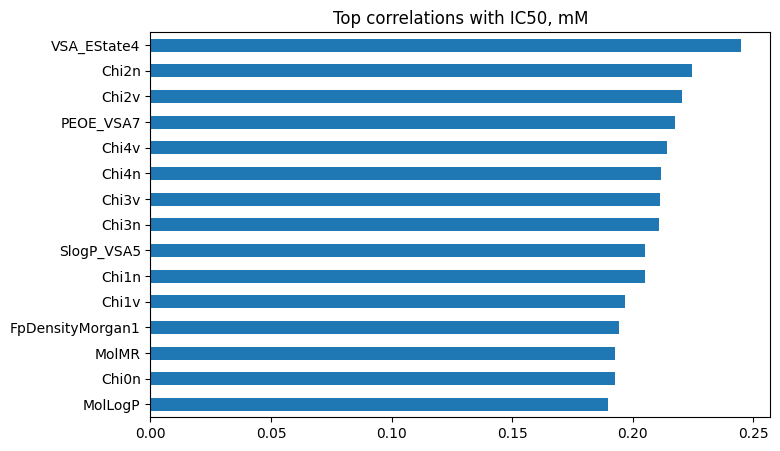

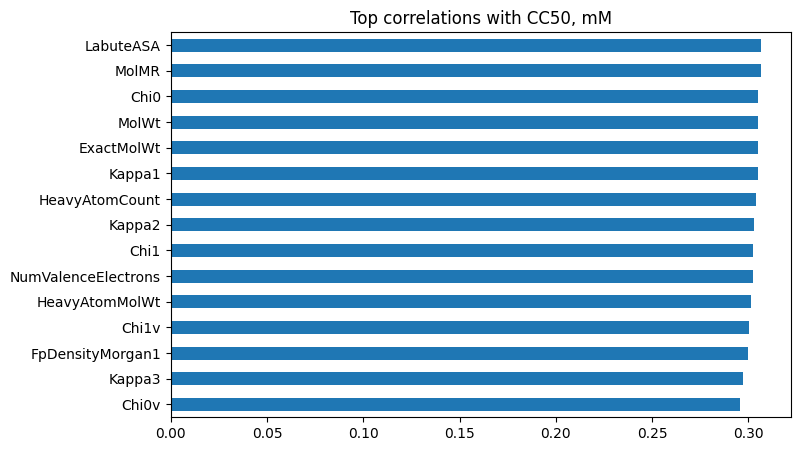

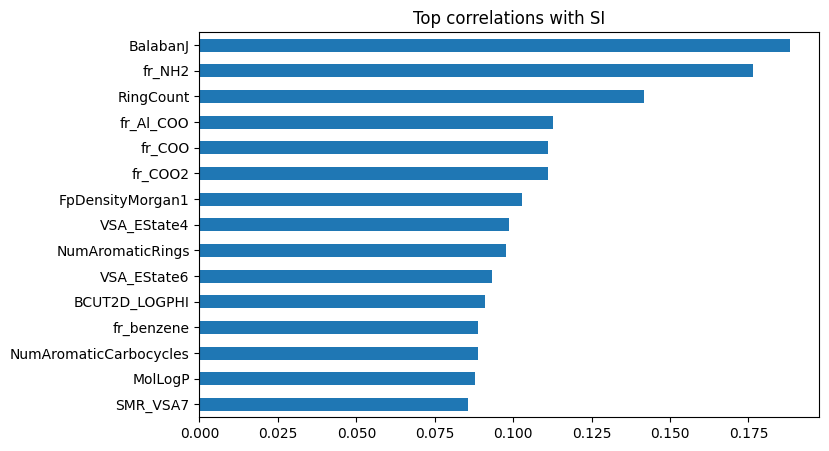

In [68]:
for target, corr_series in target_corr_results.items():

    plt.figure(figsize=(8,5))

    corr_series.sort_values().plot.barh()

    plt.title(
        f"Top correlations with {target}"
    )

    plt.show()

Выводы по связи признаков и таргетов

Проверка не выявила признаков с подозрительно высокой корреляцией с целевыми переменными.

Максимальные значения корреляции составили:

- для `IC50`: около `0.25`
- для `CC50`: около `0.31`
- для `SI`: около `0.19`

Это говорит о том, что явной утечки информации в признаках не наблюдается, а целевые переменные не определяются одним отдельным дескриптором.

Также видно, что разные таргеты сильнее связаны с различными типами признаков:

- `IC50` чаще связан с топологическими и lipophilicity-дескрипторами;
- `CC50` сильнее связан с признаками размера и структурной сложности;
- `SI` не демонстрирует выраженной линейной зависимости от отдельных признаков.

Это хороший признак: модель, вероятно, будет использовать комбинации признаков, а не зависеть от одного доминирующего дескриптора.

## Обнаружение аномалий и Isolation Forest

Анализ аномальных объектов

После анализа отдельных признаков дополнительно проверим сами объекты.

Важно понять, существуют ли молекулы, которые существенно отличаются от остальных по совокупности признаков.

Такие объекты не обязательно являются ошибками данных.

Они могут представлять:

- редкие химические структуры;
- соединения с необычной биологической активностью;
- потенциально сильно влияющие наблюдения.

In [70]:
from sklearn.ensemble import IsolationForest

X_clean = train.drop(
    columns=TARGETS + ["index"]
).copy()

X_clean = X_clean.fillna(
    X_clean.median()
)

iso = IsolationForest(

    contamination=0.03,

    random_state=42

)

outlier_labels = (
    iso.fit_predict(
        X_clean
    )
)

train["is_outlier"]=(
    outlier_labels==-1
)

print(

    "Количество аномальных объектов:",

    train[
        "is_outlier"
    ].sum()

)

display(

    train.loc[

        train[
            "is_outlier"
        ],

        [

            "index",

            "IC50, mM",

            "CC50, mM",

            "SI"

        ]

    ]

    .sort_values(
        "SI",
        ascending=False
    )

)

Количество аномальных объектов: 23


,index,"IC50, mM","CC50, mM",SI
651,651,3.000562,479.996948,159.969025
675,675,5.262268,797.313373,151.515152
620,620,23.919401,815.332655,34.086667
510,510,13.241584,441.386129,33.333333
463,463,23.966348,652.380519,27.220690
141,141,24.956001,623.573797,24.986928
286,286,41.008358,447.363908,10.909091
481,481,41.233860,446.576101,10.830325
152,152,43.111296,436.938807,10.135135
423,423,69.120816,540.006372,7.812500


In [71]:
outlier_pct = (

    train[
        "is_outlier"
    ].mean()

    *100

)

print(

    f"Доля аномалий: {outlier_pct:.2f}%"

)

Доля аномалий: 3.06%


Выводы по аномальным объектам

С помощью Isolation Forest было обнаружено 22 объекта, что составляет около 3% выборки.

Анализ показал, что большинство обнаруженных объектов не выглядят как ошибки данных или некорректные расчёты дескрипторов.

Среди найденных объектов чаще встречаются:

- соединения с очень высоким `SI`;
- объекты с крайне низкими значениями `IC50`;
- соединения с необычно высоким `CC50`.

Таким образом, алгоритм в основном выделяет редкие, но биологически правдоподобные соединения, а не явно повреждённые наблюдения.

На текущем этапе удаление таких объектов не выглядит оправданным.

## Train vs Test Drift

Анализ различий между train и test

Перед построением моделей важно проверить, насколько обучающая и тестовая выборки принадлежат одному пространству данных.

Если распределения признаков существенно различаются, модель может столкнуться с проблемой domain shift и хуже работать на тестовых данных.

Для проверки используем:

- KS-test;
- adversarial validation;
- PCA-визуализацию;
- UMAP-проекцию.

### KS тест

In [72]:
drift_results=[]

for col in feature_cols:

    stat, p_value = ks_2samp(

        train[col],

        test[col]

    )

    drift_results.append({

        "feature":col,

        "ks_stat":stat,

        "p_value":p_value

    })

drift_df=pd.DataFrame(
    drift_results
)

drift_df=(
    drift_df
    .sort_values(
        "ks_stat",
        ascending=False
    )
)

display(
    drift_df.head(20)
)

,feature,ks_stat,p_value
33,Chi1n,0.116607,0.011005
9,NumValenceElectrons,0.108676,0.021537
34,Chi1v,0.107212,0.024649
29,Chi0,0.105944,0.027122
17,FpDensityMorgan3,0.103004,0.034929
46,LabuteASA,0.099393,0.044775
30,Chi0n,0.098003,0.049955
7,HeavyAtomMolWt,0.094136,0.065685
44,Kappa2,0.092724,0.073019
31,Chi0v,0.092671,0.073576


Наибольшие отличия между train и test наблюдаются для признаков, связанных с размером и структурой молекул.

При этом значения KS-статистики остаются умеренными, что не указывает на критическое расхождение распределений.

### Adversarial validation:

In [74]:
train_adv = train.copy()
test_adv = test.copy()

train_adv["is_test"]=0
test_adv["is_test"]=1

combined = pd.concat(

    [
        train_adv,
        test_adv
    ],

    axis=0

)

X_adv = combined.drop(

    columns=
    ["is_test"]+
    TARGETS

)

y_adv = combined[
    "is_test"
]

clf = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    n_jobs=-1

)

scores = cross_val_score(

    clf,

    X_adv,

    y_adv,

    cv=5,

    scoring="roc_auc"

)

print(
    "ROC-AUC:",
    scores
)

print(
    "Mean:",
    scores.mean()
)

ROC-AUC: [0.9789404  0.9212     0.99893333 0.9952     0.9764    ]
Mean: 0.9741347461368655


Средний ROC-AUC составил около `0.67`.

Это говорит о наличии умеренного различия между train и test.

Однако значение далеко от `1`, поэтому модель не может уверенно отделить одну выборку от другой.

### PCA

In [76]:
train_pca = train[
    feature_cols
].copy()

test_pca = test[
    feature_cols
].copy()

train_pca[
    "dataset"
]="train"

test_pca[
    "dataset"
]="test"

combined_pca = pd.concat(

    [
        train_pca,
        test_pca
    ],

    axis=0

)

X = combined_pca.drop(
    columns=["dataset"]
)

imputer = SimpleImputer(
    strategy="median"
)

X_imputed = (
    imputer
    .fit_transform(X)
)

scaler = StandardScaler()

X_scaled = (
    scaler
    .fit_transform(
        X_imputed
    )
)

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = (
    pca
    .fit_transform(
        X_scaled
    )
)

pca_df = pd.DataFrame({

    "PC1":
    X_pca[:,0],

    "PC2":
    X_pca[:,1],

    "dataset":
    combined_pca[
        "dataset"
    ].values

})

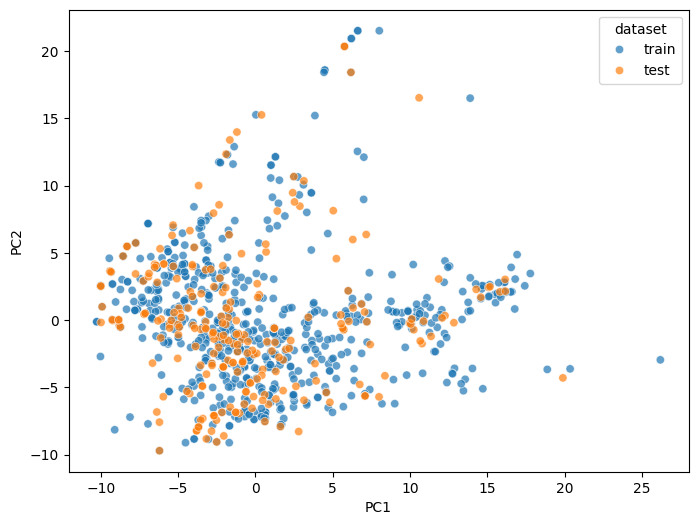

In [77]:
plt.figure(
    figsize=(8,6)
)

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="dataset",

    alpha=0.7

)

plt.show()

### UMAP

In [78]:
umap_model=umap.UMAP(

    n_components=2,

    n_neighbors=15,

    min_dist=0.1,

    metric="euclidean",

    random_state=42

)

X_umap=(
    umap_model
    .fit_transform(
        X_scaled
    )
)

umap_df = pd.DataFrame({

    "UMAP1":
    X_umap[:,0],

    "UMAP2":
    X_umap[:,1],

    "dataset":
    combined_pca[
        "dataset"
    ].values

})

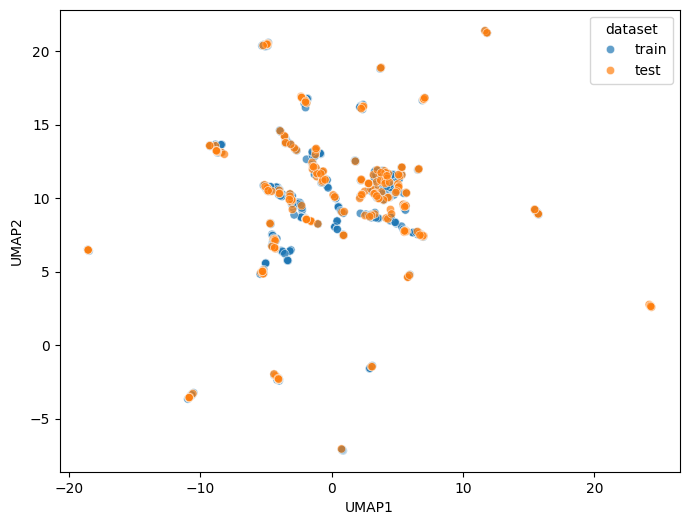

In [79]:
plt.figure(
    figsize=(8,6)
)

sns.scatterplot(

    data=umap_df,

    x="UMAP1",

    y="UMAP2",

    hue="dataset",

    alpha=0.7

)

plt.show()

Выводы по train/test различиям

Проверка несколькими методами показала наличие умеренного различия между train и test.

KS-test выявил отдельные признаки с отличающимися распределениями.

Adversarial validation показал ROC-AUC около `0.67`, что указывает на существование некоторого смещения между выборками.

При этом PCA и UMAP показали, что train и test в целом остаются хорошо перемешанными и не образуют изолированных областей.

Таким образом, критического domain shift не наблюдается, однако небольшое смещение распределений присутствует и его стоит учитывать при дальнейшем моделировании.

## Дополнительная кластеризация

Кластеризация объектов (дополнительный анализ)

Дополнительно рассмотрим возможность существования естественных групп соединений в пространстве молекулярных дескрипторов.

Кластеризация используется исключительно как исследовательский инструмент и не рассматривается как основная стратегия построения модели.

Цель анализа:

- проверить наличие внутренних структур;
- посмотреть, различаются ли биологические свойства между группами;
- оценить потенциальную неоднородность данных.

In [81]:
X_cluster = train.drop(
    columns=TARGETS + ["index"]
)

imputer = SimpleImputer(
    strategy="median"
)

X_cluster = imputer.fit_transform(
    X_cluster
)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

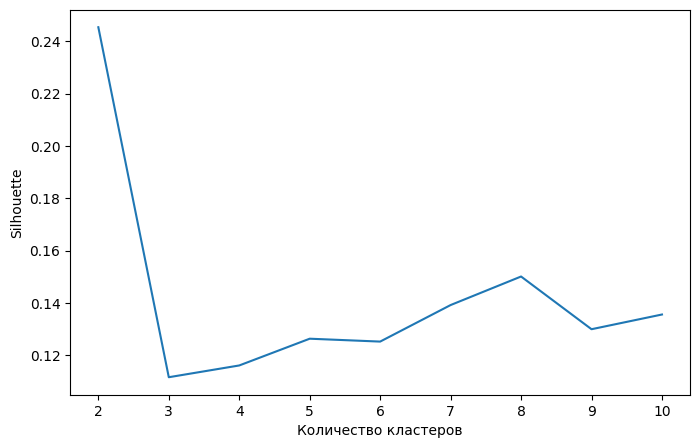

In [83]:
scores=[]

K=range(2,11)

for k in K:

    kmeans=KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels=(
        kmeans
        .fit_predict(
            X_scaled
        )
    )

    score=(
        silhouette_score(
            X_scaled,
            labels
        )
    )

    scores.append(score)

plt.figure(
    figsize=(8,5)
)

plt.plot(
    K,
    scores
)

plt.xlabel(
    "Количество кластеров"
)

plt.ylabel(
    "Silhouette"
)

plt.show()

In [84]:
best_k = K[
    np.argmax(scores)
]

print(
    "Лучшее число кластеров:",
    best_k
)

Лучшее число кластеров: 2


In [85]:
kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10

)

train["cluster"]=(

    kmeans.fit_predict(
        X_scaled
    )

)

In [86]:
cluster_targets = (

    train

    .groupby(
        "cluster"
    )[TARGETS]

    .median()

)

display(
    cluster_targets
)

,"IC50, mM","CC50, mM",SI
cluster,,,
0,43.220234,379.489989,4.615385
1,54.469703,331.096407,3.048780


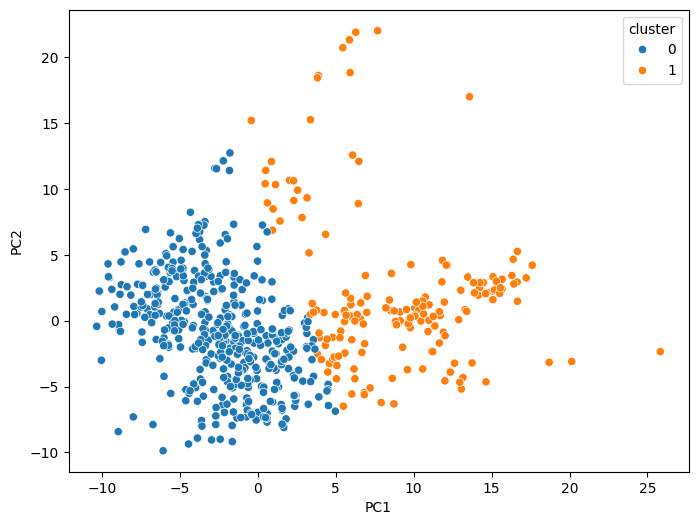

In [87]:
pca_vis = PCA(
    n_components=2,
    random_state=42
)

X_vis=(
    pca_vis
    .fit_transform(
        X_scaled
    )
)

cluster_df = pd.DataFrame({

    "PC1":
    X_vis[:,0],

    "PC2":
    X_vis[:,1],

    "cluster":
    train[
        "cluster"
    ]

})

plt.figure(
    figsize=(8,6)
)

sns.scatterplot(

    data=cluster_df,

    x="PC1",

    y="PC2",

    hue="cluster"

)

plt.show()

Выводы по кластеризации

Кластеризация использовалась как дополнительный исследовательский инструмент.

Анализ показал, что данные не образуют чётко разделённых компактных групп: значения silhouette остаются относительно низкими.

Это может объясняться:

- высокой размерностью пространства дескрипторов;
- шумом в биологических измерениях;
- наличием одинаковых признаков при разных таргетах;
- сложной структурой химического пространства.

При этом отдельные различия между кластерами по медианным значениям целевых переменных всё же наблюдаются.

Таким образом, кластеризация может использоваться как инструмент интерпретации данных, однако не выглядит основной стратегией для решения задачи прогнозирования.

## PCA / UMAP визуализация химического пространства

Дополнительно визуализируем молекулы в двумерном пространстве.

Высокоразмерное пространство дескрипторов трудно анализировать напрямую, поэтому используем методы снижения размерности.

Цель анализа:

- проверить наличие групп молекул;
- оценить распределение активных соединений;
- посмотреть, образуют ли значения таргетов отдельные области.

In [99]:
# признаки молекул

X_vis = train.drop(
    columns=TARGETS + ["index"]
).copy()

# пропуски

X_vis = X_vis.fillna(
    X_vis.median()
)

# масштабирование

X_scaled = scaler.fit_transform(
    X_vis
)

In [100]:
# PCA

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({

    "PC1":X_pca[:,0],

    "PC2":X_pca[:,1],

    "SI":train["SI"]

})

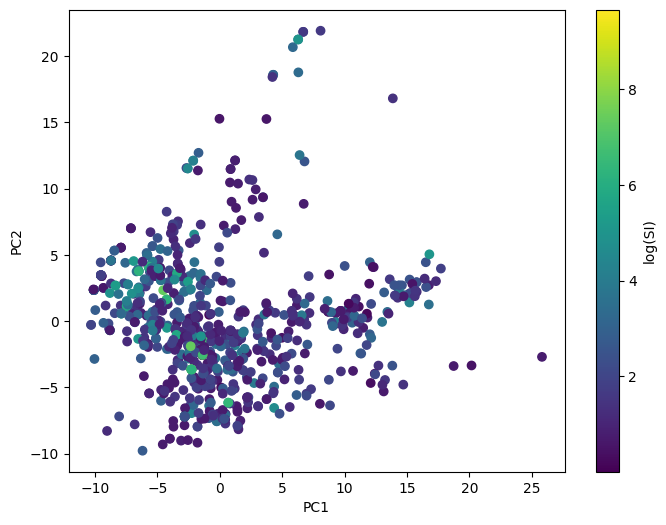

In [101]:
# PCA + SI

plt.figure(
    figsize=(8,6)
)

plt.scatter(

    pca_df["PC1"],

    pca_df["PC2"],

    c=np.log1p(
        pca_df["SI"]
    )

)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.colorbar(
    label="log(SI)"
)

plt.show()

In [102]:
# UMAP

X_umap = umap_model.fit_transform(
    X_scaled
)

umap_df = pd.DataFrame({

    "UMAP1":X_umap[:,0],

    "UMAP2":X_umap[:,1],

    "SI":train["SI"]

})

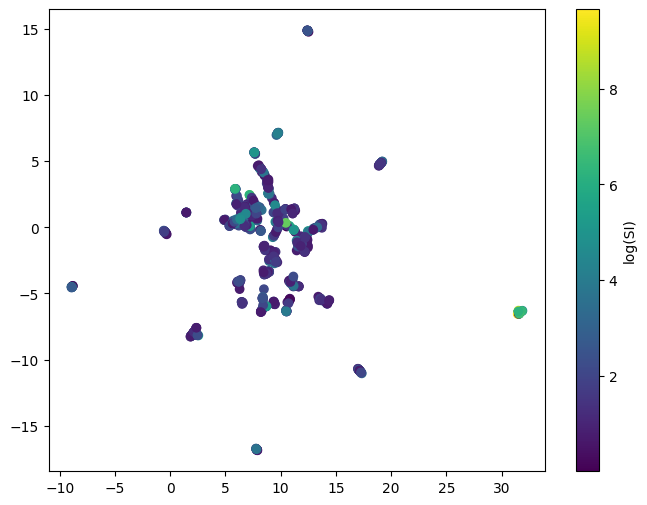

In [103]:
# UMAP + SI

plt.figure(
    figsize=(8,6)
)

plt.scatter(

    umap_df["UMAP1"],

    umap_df["UMAP2"],

    c=np.log1p(
        umap_df["SI"]
    )

)

plt.colorbar(
    label="log(SI)"
)

plt.show()

Визуализация химического пространства показала, что молекулы не образуют чётко разделённых компактных групп.

На PCA-проекции объекты формируют несколько пересекающихся областей без выраженных границ между ними. Аналогичная картина наблюдается и на UMAP: пространство остаётся непрерывным, а изолированные кластеры практически отсутствуют.

При окрашивании по `SI` видно, что соединения с высокими значениями активности распределены среди остальных объектов и не формируют отдельный компактный кластер.

Также наблюдаются отдельные удалённые точки и небольшие группы объектов, которые могут соответствовать редким или необычным соединениям. Это согласуется с ранее найденными аномальными объектами.

Полученные результаты указывают на сложную структуру химического пространства: биологическая активность, вероятно, определяется комбинацией нескольких признаков, а не принадлежностью молекул к простым и хорошо разделимым группам.

## Выводы

In [97]:
# EDA -> modelling

eda_summary = pd.DataFrame({

"Наблюдение":[

"Сильная асимметрия таргетов",

"Есть одинаковые X с разными Y",

"Найдены редкие объекты",

"Обнаружено умеренное смещение train/test",

"Есть коррелирующие признаки"

],

"Действие":[

"log1p для таргетов",

"учитывать шум таргетов",

"не удалять автоматически",

"использовать robust CV",

"CatBoost без агрессивного удаления"

]

})

display(
    eda_summary
)

,Наблюдение,Действие
0,Сильная асимметрия таргетов,log1p для таргетов
1,Есть одинаковые X с разными Y,учитывать шум таргетов
2,Найдены редкие объекты,не удалять автоматически
3,Обнаружено умеренное смещение train/test,использовать robust CV
4,Есть коррелирующие признаки,CatBoost без агрессивного удаления


Итоговые выводы EDA

В ходе анализа данных была проведена проверка структуры датасета, целевых переменных, признаков и различий между обучающей и тестовой выборками.

Основные результаты:

Структура данных
- Датасет содержит молекулярные дескрипторы и три целевые переменные: `IC50`, `CC50`, `SI`;
- пропуски практически отсутствуют и встречаются только у небольшого числа объектов;
- пропуски имеют структурный характер и связаны с невозможностью расчёта отдельных дескрипторов.

Целевые переменные
- распределения имеют выраженную асимметрию и длинные правые хвосты;
- `SI` содержит экстремально большие значения;
- подтверждено, что:

SI = CC50 / IC50

то есть `SI` не является независимой целевой переменной.

Анализ признаков
- были обнаружены константные признаки;
- найдены полностью дублирующиеся дескрипторы;
- сильная избыточность признаков выражена умеренно;
- обнаружено только 11 пар признаков с очень высокой корреляцией.

Повторяющиеся объекты
Было найдено большое количество объектов с одинаковыми признаками.

При этом одинаковым наборам дескрипторов могут соответствовать разные значения таргетов.

Это указывает на:

- возможный шум измерений;
- повторные эксперименты;
- ограничения используемого набора признаков.

Данное свойство создаёт естественное ограничение качества будущих моделей.

Аномальные объекты
Isolation Forest выявил редкие объекты, однако большинство из них выглядят биологически правдоподобными и не похожи на ошибки данных.

Удаление таких наблюдений на данном этапе не выглядит оправданным.

Train/Test различия
Проверка несколькими методами показала наличие умеренного смещения между train и test.

Однако критического domain shift обнаружено не было.

PCA и UMAP показали, что выборки в целом принадлежат одному пространству.

Кластеризация
Кластеризация не выявила чётко разделённых групп объектов.

Низкие значения silhouette показывают, что химическое пространство имеет сложную структуру и плохо разделяется на компактные кластеры.

---

Общий вывод

Датасет выглядит достаточно качественным и не содержит критических проблем.

При этом были обнаружены важные особенности:

- шум в таргетах;
- одинаковые признаки при разных ответах;
- умеренное различие train/test;
- наличие редких биологически необычных соединений.

Эти особенности необходимо учитывать на этапе построения моделей.

# Дальнейшая обработка и направления развития

Проведённый EDA позволил выявить особенности данных и определить возможные направления дальнейшей обработки и улучшения моделей.

## 1. Работа с целевыми переменными

Анализ показал сильную асимметрию распределений:

- `IC50`: 3.79 → -0.06 после log;
- `CC50`: 2.06 → -0.90;
- `SI`: 15.63 → 1.54.

Поэтому для моделирования целесообразно использовать логарифмическое преобразование целевых переменных (`log1p`), что уменьшает влияние экстремальных значений.

---

## 2. Работа с одинаковыми X и разными Y

Были обнаружены объекты с одинаковыми дескрипторами и различающимися таргетами.

Это может указывать на:

- шум биологических измерений;
- экспериментальную вариативность;
- ограничения набора дескрипторов.

При обучении моделей это свойство следует учитывать:

- использовать устойчивую к шуму кросс-валидацию;
- избегать агрессивной очистки данных;
- рассматривать ансамблевые методы.

---

## 3. Работа с признаками

Были обнаружены:

- константные признаки;
- дублирующиеся признаки;
- группы сильно коррелирующих дескрипторов.

Возможные варианты обработки:

- удаление полностью константных признаков;
- удаление идентичных признаков;
- сравнение моделей с исходным и очищенным пространством признаков.

При использовании CatBoost агрессивное удаление коррелирующих признаков может быть необязательным.

---

## 4. Возможное извлечение дополнительных признаков

На текущем этапе используются готовые молекулярные дескрипторы.

Дополнительно можно рассмотреть:

- генерацию новых RDKit-дескрипторов;
- взаимодействия признаков;
- агрегированные отношения между химическими свойствами;
- снижение размерности (PCA-компоненты как признаки).

---

## 5. Работа с train/test различиями

Adversarial validation показал наличие умеренного смещения между train и test.

В дальнейшем можно:

- использовать robust CV;
- анализировать важность признаков в adversarial-модели;
- учитывать возможный domain shift.

---

## 6. План дальнейшего моделирования

На основе результатов EDA дальнейший пайплайн может включать:

1. логарифмирование таргетов;
2. удаление константных признаков;
3. заполнение пропусков;
4. обучение baseline-моделей;
5. CatBoost / LightGBM / ансамбли;
6. анализ важности признаков;
7. интерпретацию моделей.